<h1> Plakansiksnas pārvada aprēķins <h1>

Uzdevums: Aprēķināt tāda pārvada parametrus, kas savieno horizontāli un paralēli novietotas vārpstas.

Pārvada izveidojuma shēma parādīta 1. attēlā.
 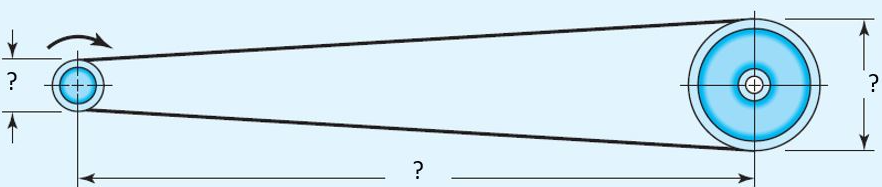
<div align="center">  1. att. Plakansiksnas pārvada shēma  <br>
<div align="left">


Veicot aprēķinu, jānoskaidro:
- siksnas parametri (veids, platums, biezums);
- nepieciešamie siksnas spriegošanas parametri;
- pārvada radītā slodze uz vārpstām.

<br>

Aprēķina izejas dati ir:
- skriemeļu asu attālums;
- pārvadāmā jauda;
- jaudas avota un piedzenamā skriemeļa rotācijas ātrums.



Pārvadu projektējot, izvēlamais vispārēja pielietojuma plakansiksu Habasit A3. Tās galvenie parametri parādīti ražotāja bukletā: <br>
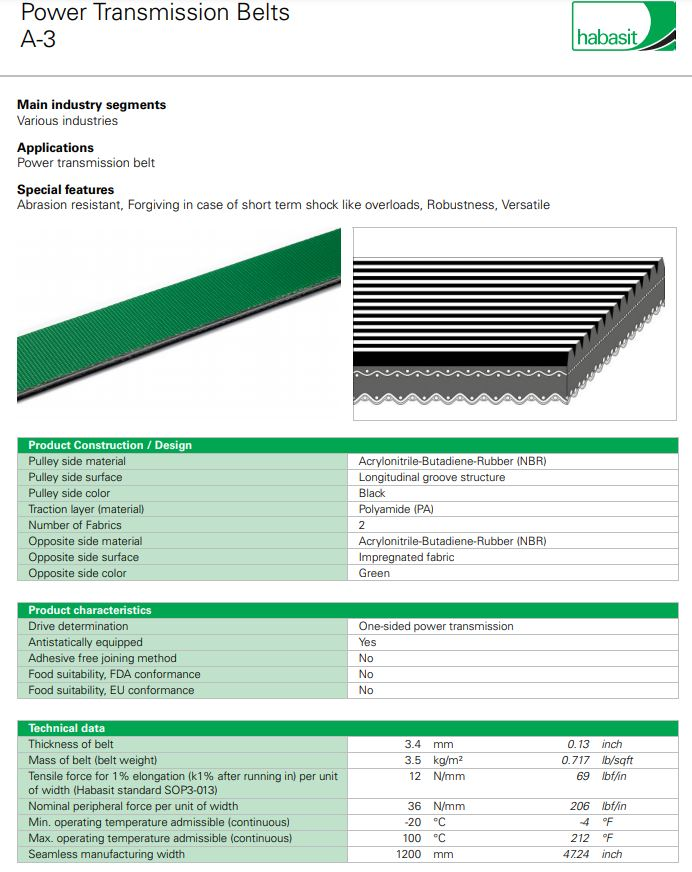
Siksnas darba virsmas berzes koeficienta vērtība ir:

 $\mu$ = 0.495. <br>
 Aprēķinu var sākt, ievadot pārvada robežparametrus:
 
 - motora rotācijas ātrums, $n_m$ [apgr./min];
 - motora jauda, P [W];
 - dzītā skriemeļa rotācijas ātrums, $n_s$ [apgr./min];
 - asu attālums [m];
 - darba režīma faktors Ks = 1.15.

 


In [1]:
n_m=3000 #motora apgriezieni

P=500 # motora jauda, W

n_s=1000 # dzenošā skriemeļa apgriezieni
C=1.5 # asu attālums, m

Ks=1.15 # darba režīma koeficients
F_un=36*1000 # siksnas nominālais aploces spēks pret siksnas platumu, N/m
t= 3.4/1000 # siksnas biezums, m
m_i=3.5 # siksnas īpatnējā masa, kg/m2
K_1= 12*1000 # stiepes spēks 1% pagarinājumam, N/m
mu=0.495 # berzes koeficients

dzenošā skriemeļa leņķiskais ātrums [rad/s]: $$\omega_d=\frac{2\pi\cdot n_m}{60}$$


In [2]:
import numpy as np

omega_d=(2*np.pi*n_m)/60
print (omega_d)

314.1592653589793


dzenošā skriemeļa griezes moments [Nm]: $$ T_d=\frac{P}{\omega_d} $$


In [3]:
T_d=(P)/omega_d
print (T_d)

1.5915494309189533


optimālais dzenošā skriemeļa diametrs [m]: $$d=\frac{60 \cdot \sqrt[3]{T_d} }{1000}$$

In [4]:
d=(60*(T_d**(1/3)))/1000
print ((d))

0.07005265949644417


Pārvada pārnesuma skaitlis:
    $$i=\frac{n_m}{n_s}$$ <br>
    Dzītā skriemeļa diametrs:
    $$ D=d\cdot i$$
  

In [5]:
i=n_m/n_s
D=d*i
print ((D))

0.2101579784893325


Nosaka siksnas aptveres leņķi (grādos) uz mazā skriemeļa:

$$ \beta_d=180-\frac {D-d}{C} \cdot 60$$
kur C  - asu attālums, m. <br>

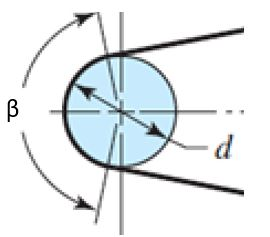


In [6]:
beta_d=180-((D-d)/C)*60
print ((beta_d))

174.39578724028448


In [7]:
beta_drad=beta_d*(np.pi/180)
print ((beta_drad))

3.0437806889504793


Nosaka siksnas pārvada aprēķinu jaudu: 
    $$P_a=P \cdot K_s$$

In [8]:
P_a=P*Ks
print ((P_a))

575.0


Nosaka siksnas pārvada aprēķinu griezes momentu:
    $$T_a=\frac {P_a} { \omega_d}$$

In [9]:
T_a=P_a/(omega_d)
print ((T_a))

1.8302818455567964


Nosaka nepieciešamo aploces spēku, lai pārvadītu aprēķinu griezes momentu:
$$ F_u= \frac {2 \cdot T_a}{d}$$

In [10]:
F_u=(2*T_a)/d
print ((F_u))

52.254457110217224


Nepieciešamais siksnas platums [m]:
$$ b= \frac {F_u}{F_{un}}$$

In [11]:
b=F_u/F_un
print ((b))

0.001451512697506034


Nosaka siksnas garuma vienības masu:
$$\gamma=m_i \cdot b$$

In [12]:
y=m_i*b
print ((y))

0.0050802944412711186


Nosaka siksnas lineāro ātrumu:

$$ v=  \frac {\omega_d \cdot d}{2}$$

In [13]:
v=omega_d*d/2
print ((v))

11.003846021922813


Nosaka gredzenspriegojumu inerces ietkemē: 
   $$ F_c=\gamma*v^2$$ <br>
   
   ![Fc.JPG](att_4.jpg)
   

In [14]:
F_c=y*pow(v,2)
print ((F_c))

0.615145558864435


Nosaka neizslīdēšanas parametra vērtību:

$$ E_f=e^{\mu \cdot \beta_{drad}}$$

In [15]:
E_f=pow(np.e,(mu*beta_drad))
print ((E_f))

4.511688352641657


Nosaka nepieciešamo sākotnējo spriegojumu:

$$ F_i=\frac {F_u}{2} \cdot \frac {E_f+1} {E_f-1}$$

In [16]:
F_i=F_u/2*(E_f+1)/(E_f-1)
print (F_i)

41.00738073914538


Slogotā zara spriegojuma spēks:

$$ F_1=F_i+F_c+\frac {F_u} {2} $$


![F1.JPG](att_5.jpg)


Brīvā zara spriegojuma spēks:

$$ F_2=F_1-F_u $$


In [17]:
F_1=F_i+F_c+F_u/2
F_2=F_1-F_u
print (F_2)

15.495297742901208


Slodze uz vārpstu: 
    
$$ F_{w}=F_1+F_2 \cdot sin {\frac{\beta_{drad}}{2}}+2 \cdot F_c$$

In [18]:
F_omega=F_1+F_2*(np.sin(beta_drad/2))+2*F_c
print (F_omega)

84.45681661828274


Nosaka nepieciešamo efektīvo siksnas garumu:

$$ L_{eff}=2 \cdot C \cdot sin {\frac{\beta_d}{2}} +\frac {\pi}{2} \cdot \left(  d+D+4 \cdot \frac {t}{2} + \frac {(D-d) \cdot (180-\beta_d)}{180} \right)$$


![Leff.JPG](att_6.jpg)


    

In [19]:
L_eff=2*C*(np.sin(beta_drad/2))+np.pi/2*(d+D+4*t/2+((D-d)*(180-beta_d)/180))
print (L_eff)

3.4541002665211686


Nosaka nepieciešamo relatīvo sākotnējo pagarinājumu:

$$ \epsilon_0=\frac {F_i+F_c} {b \cdot K_1} $$

Nosaka nepieciešamo sākotnējo pagarinājumu:

$$ X_\epsilon=\frac {L_{eff} \cdot \epsilon_0} {2 \cdot 100} $$


![xe.JPG](att_7.jpg)

In [20]:
e_0=(F_i+F_c)/(b*K_1)
print (e_0)

2.389606280487303


In [22]:
X_e=(L_eff*e_0)/(2*100)
print (X_e)

0.041269698451559256
